# Análisis de Seguridad: Vulnerabilidades y Hallazgos

In [12]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de estilos para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Mapa de colores para severidad
COLOR_MAP = {
    'critical': '#d9534f',
    'high': '#f0ad4e',
    'medium': '#5bc0de',
    'low': '#5cb85c',
    'info': '#6c757d'
}
SEV_ORDER = ['critical', 'high', 'medium', 'low', 'info']

# Cargar datasets
RESULTS_FOLDER = Path("../results")
TOOL_ANALYSIS_FOLDER = RESULTS_FOLDER / "tool-analysis"
TOOL_ANALYSIS_FOLDER.mkdir(parents=True, exist_ok=True)

findings_df = pd.read_csv(RESULTS_FOLDER / "dataset/findings.csv")
findings_df['severity'] = findings_df['severity'].astype(str).str.lower()

print(f"Buscando archivos en: {RESULTS_FOLDER.resolve()}")
print(f"✓ Total de hallazgos cargados: {len(findings_df)}")
print(f"✓ Repositorios únicos: {findings_df['repo'].nunique()}")

Buscando archivos en: /workspaces/Proyecto-analisis-cs/results
✓ Total de hallazgos cargados: 311
✓ Repositorios únicos: 28


## 1. Distribución de Vulnerabilidades por Severidad

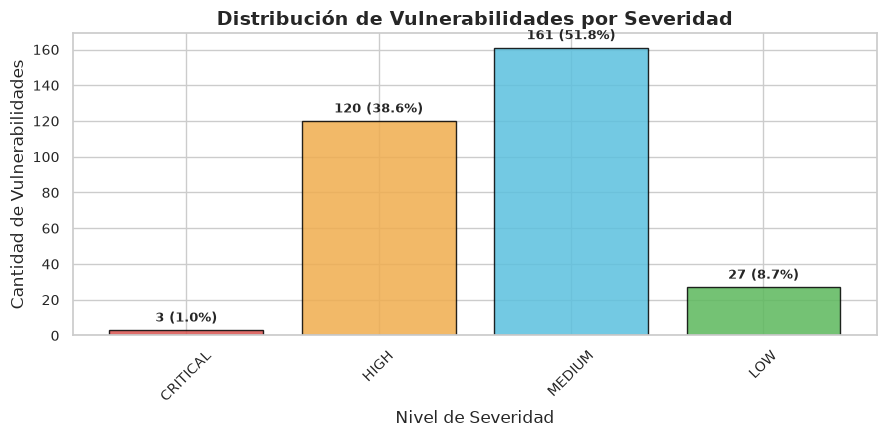

In [13]:
# Contar y ordenar por severidad
severity_counts = findings_df['severity'].value_counts()
existing_order = [s for s in SEV_ORDER if s in severity_counts.index]
severity_counts = severity_counts.reindex(existing_order)

# Exportar datos a JSON
severity_summary = severity_counts.reset_index()
severity_summary.columns = ['severity', 'count']
severity_summary.to_json(TOOL_ANALYSIS_FOLDER / "severity_summary.json", orient='records', indent=4)

# Graficar
fig, ax = plt.subplots(figsize=(9, 4.5))
bar_colors = [COLOR_MAP.get(s, '#777777') for s in severity_counts.index]
bars = ax.bar([s.upper() for s in severity_counts.index], severity_counts.values, color=bar_colors, edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / len(findings_df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + (len(findings_df) * 0.01), f'{yval} ({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_title("Distribución de Vulnerabilidades por Severidad", fontsize=14, fontweight='bold')
ax.set_xlabel("Nivel de Severidad")
ax.set_ylabel("Cantidad de Vulnerabilidades")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La distribución del nivel de severidad permite identificar el impacto potencial de los hallazgos. Una mayor concentración de eventos en categorías críticas e altas representa un riesgo significativo para la organización, aumentando la probabilidad de incidentes de seguridad.

## 2. Comparativa por Herramienta (SAST vs SCA)

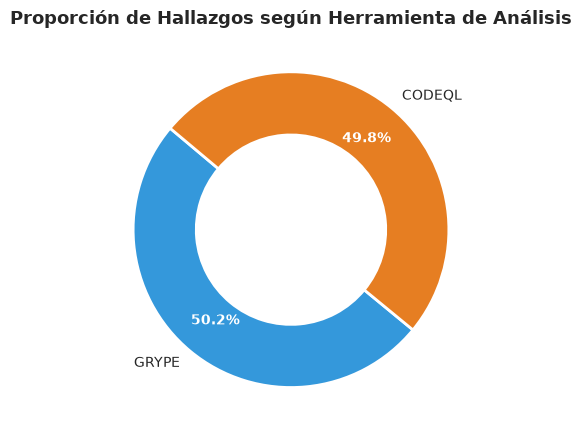

In [14]:
tool_counts = findings_df['tool'].value_counts()

# Exportar datos a JSON
tool_summary = tool_counts.reset_index()
tool_summary.columns = ['tool', 'count']
tool_summary.to_json(TOOL_ANALYSIS_FOLDER / "tool_summary.json", orient='records', indent=4)

# Graficar dona/pie
fig, ax = plt.subplots(figsize=(6, 4.5))
colors_tools = ['#3498db', '#e67e22'] if len(tool_counts) == 2 else sns.color_palette("Set2")
wedges, texts, autotexts = ax.pie(
    tool_counts, 
    labels=[t.upper() for t in tool_counts.index], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_tools,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)
plt.setp(autotexts, size=10, weight="bold", color="white")
ax.set_title("Proporción de Hallazgos según Herramienta de Análisis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Matriz de Severidad por Herramienta

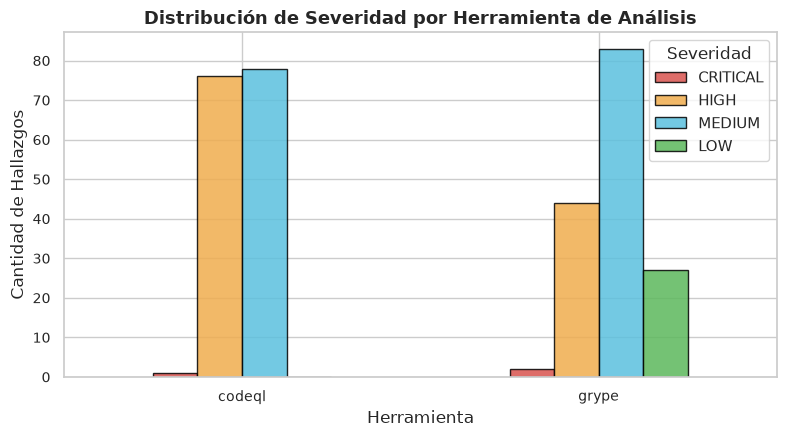

In [15]:
cross_tool_sev = pd.crosstab(findings_df['tool'], findings_df['severity'])
cross_cols = [s for s in SEV_ORDER if s in cross_tool_sev.columns]
cross_tool_sev = cross_tool_sev[cross_cols]

# Exportar JSON limpio (arregla el error de columnas)
cross_export = cross_tool_sev.reset_index()
cross_export.columns.name = None
cross_export.to_json(TOOL_ANALYSIS_FOLDER / "tool_severity_cross.json", orient='records', indent=4)

# Graficar barras agrupadas
fig, ax = plt.subplots(figsize=(8, 4.5))
cross_tool_sev.plot(
    kind='bar', 
    ax=ax, 
    color=[COLOR_MAP.get(c, '#777777') for c in cross_cols], 
    edgecolor='black', 
    alpha=0.85
)
ax.set_title("Distribución de Severidad por Herramienta de Análisis", fontsize=13, fontweight='bold')
ax.set_xlabel("Herramienta")
ax.set_ylabel("Cantidad de Hallazgos")
plt.xticks(rotation=0)
plt.legend(title="Severidad", labels=[s.upper() for s in cross_cols])
plt.tight_layout()
plt.show()

## 4. Top Repositorios con Mayor Cantidad de Vulnerabilidades

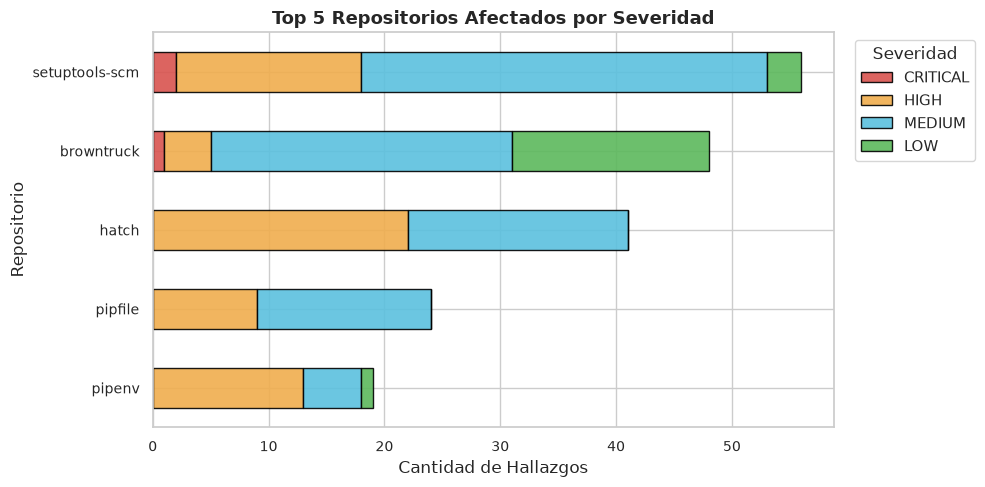

In [16]:
top_repos_list = findings_df['repo'].value_counts().head(5).index
df_top5 = findings_df[findings_df['repo'].isin(top_repos_list)]

repo_sev_matrix = pd.crosstab(df_top5['repo'], df_top5['severity'])
repo_sev_cols = [s for s in SEV_ORDER if s in repo_sev_matrix.columns]
repo_sev_matrix = repo_sev_matrix.loc[top_repos_list][repo_sev_cols]

# Exportar JSON
top_repos_df = findings_df['repo'].value_counts().head(5).reset_index()
top_repos_df.columns = ['repo_name', 'count']
top_repos_df.to_json(TOOL_ANALYSIS_FOLDER / "top_repos.json", orient='records', indent=4)

# Graficar barras apiladas
fig, ax = plt.subplots(figsize=(10, 5))
repo_sev_matrix.plot(
    kind='barh', 
    stacked=True, 
    ax=ax, 
    color=[COLOR_MAP.get(c, '#777777') for c in repo_sev_cols], 
    edgecolor='black', 
    alpha=0.9
)
ax.set_title("Top 5 Repositorios Afectados por Severidad", fontsize=13, fontweight='bold')
ax.set_xlabel("Cantidad de Hallazgos")
ax.set_ylabel("Repositorio")
ax.invert_yaxis()
ax.legend(title="Severidad", labels=[s.upper() for s in repo_sev_cols], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Informe de Análisis de Seguridad y Vulnerabilidades
**Componente:** Analyzer (Segundo Integrante)  
**Alcance:** 28 Repositorios auditados | 311 Hallazgos totales  

---

## 1. Introducción y Contexto
El presente análisis evalúa la postura de seguridad de **28 repositorios** de la organización objetivo mediante herramientas de Análisis Estático de Código SAST (**CodeQL**) y análisis de dependencias SCA/SBOM (**Grype**).

> **Objetivo:** Identificar concentraciones de riesgo, patrones de vulnerabilidad recurrentes y estructurar los datasets procesados para su posterior consumo en el dashboard interactivo (**Visualizer**).

---

## 2. Resultados Principales y Distribución de Riesgo

| Métrica | Valor | Observación |
| :--- | :--- | :--- |
| **Total Hallazgos** | **311** | Registrados en el dataset unificado |
| **Repositorios Afectados** | **28** | 100% de la muestra evaluada |
| **Severidad Crítica** | **3 (1.0%)** | Requieren atención e intervención inmediata |
| **Severidad Alta** | **120 (38.6%)** | Elevado riesgo de explotación |
| **Severidad Media** | **161 (51.8%)** | Principal volumen de hallazgos (cadena de suministro) |
| **Severidad Baja** | **27 (8.6%)** | Oportunidades de mejora y hardening de código |

---

## 3. Patrones Identificados e Impacto Organizacional

1. **Equilibrio de Vectores de Ataque (SAST vs. SCA):**
   * **CodeQL (Código Fuente):** 155 hallazgos (49.8%).
   * **Grype (Dependencias / SBOM):** 156 hallazgos (50.2%).
   * *Conclusión:* El riesgo está distribuido equitativamente entre errores de codificación propia y vulnerabilidades heredadas en librerías de terceros.

2. **Concentración del Riesgo (Principio de Pareto):**
   * El **90.4% de los hallazgos** se concentra en severidades Media y Alta (281 vulnerabilidades).
   * Repositorios con mayor densidad de fallas: `setuptools-scm` (56), `browntruck` (48) y `hatch` (41).

3. **Debilidades Más Frecuentes (Top CWEs):**
   * Predominancia de **CWE-829** (Inclusión de dependencias de terceros no confiables) y **CWE-275** (Permisos deficientes o inseguros).

   ---

## 4. Conclusiones y Plan de Acción

> **Plan de Mitigación Recomendado:**
> 1. **Prioridad 1 (Inmediata):** Corregir de manera prioritaria las **3 vulnerabilidades Críticas** y las **120 de nivel Alto**.
> 2. **Prioridad 2 (Cadena de Suministro):** Actualizar las dependencias reportadas por Grype para eliminar los 161 hallazgos de nivel Medio.
> 3. **Prioridad 3 (Foco en Repos Críticos):** Concentrar los esfuerzos del equipo de desarrollo en el Top 5 de repositorios (`setuptools-scm`, `browntruck`, `hatch`, `pipfile`, `pipenv`).

---
*Archivos JSON generados y estructurados exitosamente en `results/tool-analysis/` para la fase de Visualización.*